In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


# Task
Build, train, and evaluate a Hierarchical Attention Network for Multi-Scale MRI (HAN-MRI) model for brain tumor detection using the dataset located at "/kaggle/input/brain-tumor-mri-dataset". This includes preparing the dataset, implementing the HAN-MRI architecture, configuring training parameters, training the model, evaluating its performance, and summarizing the entire process along with insights gained from attention maps.

## Prepare Dataset for HAN-MRI

### Subtask:
Load the MRI images from the dataset path ('/kaggle/input/brain-tumor-mri-dataset'), preprocess them (e.g., resizing, normalization), and split the data into training, validation, and test sets. Create data loaders for efficient batch processing.


**Reasoning**:
The first step in preparing the dataset is to understand its structure by exploring the contents of the provided dataset path.



In [16]:
import os

# List the contents of the dataset path to understand its structure
print(f"Contents of the dataset path '{path}':")
for item in os.listdir(path):
    print(item)

Contents of the dataset path '/kaggle/input/brain-tumor-mri-dataset':
Training
Testing


**Reasoning**:
Now that the top-level directories (Training and Testing) are identified, the next step is to explore the contents of the 'Training' directory to understand how the images are organized, specifically the class structure.



In [17]:
import os

# Explore the 'Training' directory to understand its structure
training_path = os.path.join(path, 'Training')
print(f"\nContents of the 'Training' directory '{training_path}':")
for item in os.listdir(training_path):
    print(item)



Contents of the 'Training' directory '/kaggle/input/brain-tumor-mri-dataset/Training':
pituitary
notumor
meningioma
glioma


**Reasoning**:
After exploring the 'Training' directory, the next logical step is to explore the 'Testing' directory to understand its structure, especially if it contains similar class subdirectories as 'Training'. This helps confirm the dataset's organization for both splits.



In [18]:
import os

# Explore the 'Testing' directory to understand its structure
testing_path = os.path.join(path, 'Testing')
print(f"\nContents of the 'Testing' directory '{testing_path}':")
for item in os.listdir(testing_path):
    print(item)


Contents of the 'Testing' directory '/kaggle/input/brain-tumor-mri-dataset/Testing':
pituitary
notumor
meningioma
glioma


**Reasoning**:
Now that the dataset structure is understood, the next step is to define the image preprocessing steps, including resizing and normalization, and then load the images using an appropriate dataset class. This will involve defining transformations and creating a `Dataset` object for the training data.



In [19]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Define image transformations for preprocessing
# Resize images to a consistent size (e.g., 224x224 for common CNNs)
# Convert images to PyTorch tensors
# Normalize pixel values (e.g., to mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] for ImageNet pre-trained models)
# Since these are MRI images, custom mean/std might be better, but ImageNet values are a common starting point.

# Define image size (e.g., 224 for common CNN architectures)
IMAGE_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Resize images
    transforms.ToTensor(),                        # Convert to PyTorch tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalize to [-1, 1]
])

# Load the training dataset using ImageFolder
training_path = os.path.join(path, 'Training')
train_dataset_full = ImageFolder(root=training_path, transform=transform)

# Load the testing dataset using ImageFolder
testing_path = os.path.join(path, 'Testing')
test_dataset = ImageFolder(root=testing_path, transform=transform)

print(f"Number of images in full training dataset: {len(train_dataset_full)}")
print(f"Number of images in test dataset: {len(test_dataset)}")
print(f"Classes: {train_dataset_full.classes}")

Number of images in full training dataset: 5712
Number of images in test dataset: 1311
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


**Reasoning**:
With the full training dataset loaded, the next step is to split it into distinct training and validation sets, as specified in the subtask. After splitting, DataLoaders will be created for the training, validation, and test sets to enable efficient batch processing during model training.



In [20]:
import torch
from torch.utils.data import DataLoader, random_split

# Define split ratios
TRAIN_RATIO = 0.8  # 80% for actual training
VAL_RATIO = 0.2    # 20% for validation (of the original training set)

# Calculate sizes for training and validation sets
train_size = int(TRAIN_RATIO * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

# Split the full training dataset into training and validation sets
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

# Define batch size for DataLoaders
BATCH_SIZE = 32

# Create DataLoaders for training, validation, and test sets
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of images in actual training set: {len(train_dataset)}")
print(f"Number of images in validation set: {len(val_dataset)}")
print(f"Number of images in test set (from original split): {len(test_dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of images in actual training set: 4569
Number of images in validation set: 1143
Number of images in test set (from original split): 1311
Batch size: 32
Number of training batches: 143
Number of validation batches: 36
Number of test batches: 41


## Implement HAN-MRI Architecture Components

### Subtask:
Define the individual building blocks of the HAN-MRI model in a suitable deep learning framework. This includes implementing the 'Patch-level CNN encoder', 'Local window attention', 'Hierarchical pooling', and 'Sparse global attention' modules as described in the architecture details.


**Reasoning**:
The first step in implementing the HAN-MRI architecture is to define the `PatchLevelCNNEncoder` module. This module will take the input images and extract initial patch-level feature representations using a series of convolutional layers, activation functions, and pooling layers.



In [21]:
import torch.nn as nn
import torch.nn.functional as F

# Define the Patch-level CNN encoder
class PatchLevelCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, out_channels=64, image_size=224):
        super(PatchLevelCNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Input x: (batch_size, in_channels, H, W)
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Output x: (batch_size, out_channels, H_reduced, W_reduced)
        return x

print("PatchLevelCNNEncoder module defined.")

PatchLevelCNNEncoder module defined.


**Reasoning**:
With the `PatchLevelCNNEncoder` defined, the next step is to implement the `LocalWindowAttention` module. This module will take patch-level features within a local window and apply an attention mechanism to aggregate them into a local context vector, as specified in the subtask instructions.



In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the Local Window Attention module
class LocalWindowAttention(nn.Module):
    def __init__(self, feature_dim, num_heads=1):
        super(LocalWindowAttention, self).__init__()
        self.num_heads = num_heads
        self.feature_dim = feature_dim
        self.head_dim = feature_dim // num_heads
        assert self.head_dim * num_heads == self.feature_dim, "feature_dim must be divisible by num_heads"

        self.query_proj = nn.Linear(feature_dim, feature_dim)
        self.key_proj = nn.Linear(feature_dim, feature_dim)
        self.value_proj = nn.Linear(feature_dim, feature_dim)
        self.out_proj = nn.Linear(feature_dim, feature_dim)

    def forward(self, x): # x: (batch_size, num_patches_in_window, feature_dim)
        batch_size, num_patches, _ = x.size()

        queries = self.query_proj(x).view(batch_size, num_patches, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.key_proj(x).view(batch_size, num_patches, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.value_proj(x).view(batch_size, num_patches, self.num_heads, self.head_dim).transpose(1, 2)

        # Attention mechanism
        attention_scores = torch.matmul(queries, keys.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)

        # Weighted sum of values
        attended_values = torch.matmul(attention_weights, values)
        attended_values = attended_values.transpose(1, 2).contiguous().view(batch_size, num_patches, self.feature_dim)

        # Output projection
        output = self.out_proj(attended_values)
        # For local window attention, we often aggregate these attention outputs further,
        # for simplicity here, we can average them or take the output of a specific patch
        # or return all of them to be pooled later. For this subtask, let's assume it outputs
        # the aggregated features for the window (e.g., by mean pooling).
        # A common approach is to output a single vector representing the window.
        return output.mean(dim=1) # (batch_size, feature_dim)

print("LocalWindowAttention module defined.")

LocalWindowAttention module defined.


**Reasoning**:
With the `PatchLevelCNNEncoder` and `LocalWindowAttention` modules defined, the next step is to implement the `HierarchicalPooling` module. This module is responsible for performing hierarchical aggregation of local context vectors from different windows or scales to create a more comprehensive representation of the image's regions, as outlined in the subtask instructions.



In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the Hierarchical Pooling module
class HierarchicalPooling(nn.Module):
    def __init__(self, feature_dim):
        super(HierarchicalPooling, self).__init__()
        # This module aggregates local context vectors (e.g., from multiple windows).
        # A common approach for 'pooling' a sequence of vectors into one is average pooling.
        # AdaptiveAvgPool1d can handle varying numbers of input vectors.
        self.pooling_layer = nn.AdaptiveAvgPool1d(1) # Pools across the sequence dimension to 1

    def forward(self, x):
        # x is expected to be (batch_size, num_local_context_vectors, feature_dim)
        # For AdaptiveAvgPool1d, the input should be (batch_size, feature_dim, num_local_context_vectors)
        x = x.permute(0, 2, 1) # Rearrange dimensions
        pooled_features = self.pooling_layer(x).squeeze(2) # Apply pooling and remove the singleton dimension
        # Output will be (batch_size, feature_dim)
        return pooled_features

print("HierarchicalPooling module defined.")

HierarchicalPooling module defined.


**Reasoning**:
With the `PatchLevelCNNEncoder`, `LocalWindowAttention`, and `HierarchicalPooling` modules defined, the final architectural component to implement for the HAN-MRI model, as per the subtask instructions, is the `SparseGlobalAttention` module. This module will take the hierarchically pooled features and apply a sparse attention mechanism to focus on the most relevant global features for the classification task.



In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the Sparse Global Attention module
class SparseGlobalAttention(nn.Module):
    def __init__(self, feature_dim, num_classes):
        super(SparseGlobalAttention, self).__init__()
        self.attention_fc = nn.Linear(feature_dim, num_classes) # For sparse attention weights per class

    def forward(self, x): # x: (batch_size, feature_dim)
        # Apply a linear layer to get attention scores for each class
        attention_scores = self.attention_fc(x)

        # Apply a sparse activation (e.g., Sparsemax or a custom sparse mechanism)
        # For simplicity and common PyTorch usage, let's use a softmax here
        # as a stand-in for 'attention weights' which can be interpreted sparsely
        # if only a few scores are high. True sparsemax requires custom implementation.
        # If the goal is explicit sparsity, one might need to implement a sparsemax
        # or similar layer, or apply a threshold.

        # For now, let's just interpret these scores as representing global attention,
        # where higher scores for certain 'patches' (here, the aggregated feature vector)
        # imply higher relevance for specific classes.
        # The output directly gives us logits for each class based on the global features.
        return attention_scores # (batch_size, num_classes) - These are essentially the final logits

print("SparseGlobalAttention module defined.")

SparseGlobalAttention module defined.


## Assemble Full HAN-MRI Model

### Subtask:
Combine the implemented components from the previous step to construct the complete Hierarchical Attention Network for Multi-Scale MRI (HAN-MRI) model architecture.


**Reasoning**:
Now that all the individual components of the HAN-MRI model are defined, the next step is to combine them into a single, cohesive `HANMRIModel` class. This involves initializing each component and defining the forward pass that dictates the data flow through the entire architecture as specified in the subtask instructions.



In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Assuming PatchLevelCNNEncoder, LocalWindowAttention, HierarchicalPooling,
# and SparseGlobalAttention classes are already defined and available in the current environment.

class HANMRIModel(nn.Module):
    def __init__(self, in_channels=3, feature_dim=64, image_size=224, num_classes=4, window_size=7):
        super(HANMRIModel, self).__init__()
        self.feature_dim = feature_dim
        self.num_classes = num_classes
        self.image_size = image_size
        self.window_size = window_size

        # 1. Patch-level CNN encoder
        self.cnn_encoder = PatchLevelCNNEncoder(in_channels=in_channels, out_channels=feature_dim, image_size=image_size)

        # Calculate feature map dimensions after CNN encoder
        # (image_size / 2 / 2) = image_size / 4
        self.feature_map_size = image_size // 4 # e.g., 224 // 4 = 56

        # Ensure window size divides the feature map size
        assert self.feature_map_size % self.window_size == 0, "Feature map size must be divisible by window size"
        self.num_windows_per_dim = self.feature_map_size // self.window_size # e.g., 56 // 7 = 8
        self.total_num_windows = self.num_windows_per_dim * self.num_windows_per_dim # e.g., 8 * 8 = 64

        # 2. Local window attention
        self.local_attention = LocalWindowAttention(feature_dim=feature_dim)

        # 3. Hierarchical pooling
        self.hierarchical_pooling = HierarchicalPooling(feature_dim=feature_dim)

        # 4. Sparse global attention
        self.global_attention = SparseGlobalAttention(feature_dim=feature_dim, num_classes=num_classes)

    def forward(self, x):
        batch_size = x.size(0)

        # 1. Pass through Patch-level CNN encoder
        # x: (batch_size, in_channels, image_size, image_size) -> (batch_size, feature_dim, feature_map_size, feature_map_size)
        cnn_features = self.cnn_encoder(x)

        # 2. Apply Local Window Attention
        local_context_vectors = []
        for i in range(0, self.feature_map_size, self.window_size):
            for j in range(0, self.feature_map_size, self.window_size):
                # Extract features for the current window
                # window_features: (batch_size, feature_dim, window_size, window_size)
                window_features = cnn_features[:, :, i:i+self.window_size, j:j+self.window_size]

                # Reshape for LocalWindowAttention: (batch_size, window_size*window_size, feature_dim)
                window_features_reshaped = window_features.permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.feature_dim)

                # Pass through LocalWindowAttention
                # local_context: (batch_size, feature_dim)
                local_context = self.local_attention(window_features_reshaped)
                local_context_vectors.append(local_context)

        # Stack all local context vectors: (batch_size, total_num_windows, feature_dim)
        stacked_local_contexts = torch.stack(local_context_vectors, dim=1)

        # 3. Hierarchical Pooling
        # global_features: (batch_size, feature_dim)
        global_features = self.hierarchical_pooling(stacked_local_contexts)

        # 4. Sparse Global Attention
        # logits: (batch_size, num_classes)
        logits = self.global_attention(global_features)

        return logits

print("HANMRIModel class defined, combining all architectural components.")


HANMRIModel class defined, combining all architectural components.


## Configure Training Parameters

### Subtask:
Set up the loss function (e.g., Cross-Entropy for classification or a suitable loss for segmentation/regression depending on the specific task), select an optimizer (e.g., Adam), and define training hyperparameters such as the number of epochs, batch size, and learning rate.


**Reasoning**:
To configure the training parameters, I will first determine the number of output classes from the loaded dataset, then instantiate the HAN-MRI model, set up the device for training (GPU if available), define the loss function and optimizer, and finally establish the training hyperparameters like learning rate and number of epochs.



In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Determine the number of output classes
num_classes = len(train_dataset_full.classes)
print(f"Number of classes: {num_classes}")

# Define model parameters
IN_CHANNELS = 3  # RGB images
FEATURE_DIM = 64 # Output feature dimension from CNN encoder
WINDOW_SIZE = 7  # Size of the local attention window, must divide IMAGE_SIZE // 4

# 2. Instantiate the HANMRIModel
model = HANMRIModel(
    in_channels=IN_CHANNELS,
    feature_dim=FEATURE_DIM,
    image_size=IMAGE_SIZE,
    num_classes=num_classes,
    window_size=WINDOW_SIZE
)

# 3. Check for GPU and move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

# 4. Define the loss function
# For multi-class classification, CrossEntropyLoss is appropriate.
criterion = nn.CrossEntropyLoss()
print("Loss function: CrossEntropyLoss")

# 5. Define the optimizer
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Optimizer: Adam with learning rate {LEARNING_RATE}")

# 6. Define training hyperparameters
NUM_EPOCHS = 20

print(f"Number of epochs: {NUM_EPOCHS}")

print("Model, loss function, optimizer, and training hyperparameters configured.")

Number of classes: 4
Using device: cpu
Loss function: CrossEntropyLoss
Optimizer: Adam with learning rate 0.001
Number of epochs: 20
Model, loss function, optimizer, and training hyperparameters configured.


## Train the HAN-MRI Model with Progress Bar

### Subtask:
Implement and execute the training loop for the HAN-MRI model, incorporating `tqdm` to display a progress bar for both training and validation steps within each epoch. This involves iterating through the training data, performing forward and backward passes, updating model weights, and including validation checks, all while visualizing the progress.


**Reasoning**:
To implement the training loop with progress bars as instructed, I need to import the `tqdm` library and integrate it into both the training and validation loops, updating the progress bar descriptions with relevant metrics. Since the previous training cell was interrupted, I will re-implement the full training loop with `tqdm`.



In [28]:
from tqdm.notebook import tqdm

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    model.train()  # Set model to training mode
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    # Training loop with tqdm progress bar
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (Train)")
    for i, (inputs, labels) in enumerate(train_loop):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Update progress bar description
        train_loop.set_postfix(loss=running_train_loss/total_train, acc=100.*correct_train/total_train)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_accuracy = 100 * correct_train / total_train

    # Validation loop with tqdm progress bar
    model.eval()  # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # Disable gradient calculation for validation
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (Val)")
        for i, (inputs, labels) in enumerate(val_loop):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            # Update progress bar description
            val_loop.set_postfix(loss=running_val_loss/total_val, acc=100.*correct_val/total_val)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = 100 * correct_val / total_val

    # Print epoch statistics
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} - '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}% - '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.2f}%')

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

print("Training complete.")

Epoch 1/20 (Train):   0%|          | 0/143 [00:00<?, ?it/s]

Epoch 1/20 (Val):   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 1/20 - Train Loss: 0.8892, Train Acc: 64.48% - Val Loss: 0.9572, Val Acc: 66.84%


Epoch 2/20 (Train):   0%|          | 0/143 [00:00<?, ?it/s]

Epoch 2/20 (Val):   0%|          | 0/36 [00:00<?, ?it/s]

...

Epoch 19/20 (Val):   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 19/20 - Train Loss: 0.3949, Train Acc: 84.96% - Val Loss: 1.2068, Val Acc: 57.66%


Epoch 20/20 (Train):   0%|          | 0/143 [00:00<?, ?it/s]

Epoch 20/20 (Val):   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 20/20 - Train Loss: 0.3981, Train Acc: 85.42% - Val Loss: 1.2848, Val Acc: 67.10%
Training complete.


## Evaluate and Visualize Model Performance

### Subtask:
Evaluate the trained HAN-MRI model on the test set using appropriate classification metrics and visualize sample predictions along with training/validation performance curves. If possible, consider how to visualize attention maps.


**Reasoning**:
The first step in evaluating the model is to iterate through the test dataset, collect the true labels and the model's predictions, and then calculate key classification metrics such as accuracy, precision, recall, and F1-score.



In [29]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Set the model to evaluation mode
model.eval()

# 2. Initialize empty lists to store all true labels and all predicted labels
all_labels = []
all_predictions = []

# 3. Iterate through the test_loader with torch.no_grad() enabled
with torch.no_grad():
    print("Evaluating model on test set...")
    for inputs, labels in test_loader:
        # 4. Move the inputs and labels to the appropriate device
        inputs, labels = inputs.to(device), labels.to(device)

        # 5. Perform a forward pass to get the model's outputs
        outputs = model(inputs)

        # 6. Get the predicted class
        _, predicted = torch.max(outputs.data, 1)

        # 7. Append the true labels and predicted labels to their respective lists
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# 8. Convert all_labels and all_predictions to NumPy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# 9. Calculate and print overall metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test Precision (weighted): {precision:.4f}")
print(f"Test Recall (weighted): {recall:.4f}")
print(f"Test F1-score (weighted): {f1:.4f}")

print("Model evaluation complete and metrics calculated.")

Evaluating model on test set...

Test Accuracy: 0.6407
Test Precision (weighted): 0.7157
Test Recall (weighted): 0.6407
Test F1-score (weighted): 0.5521
Model evaluation complete and metrics calculated.


**Reasoning**:
Now that the overall classification metrics have been calculated, the next step is to visualize the model's performance in more detail by generating and plotting a confusion matrix. This will show how many samples of each class were correctly and incorrectly classified.



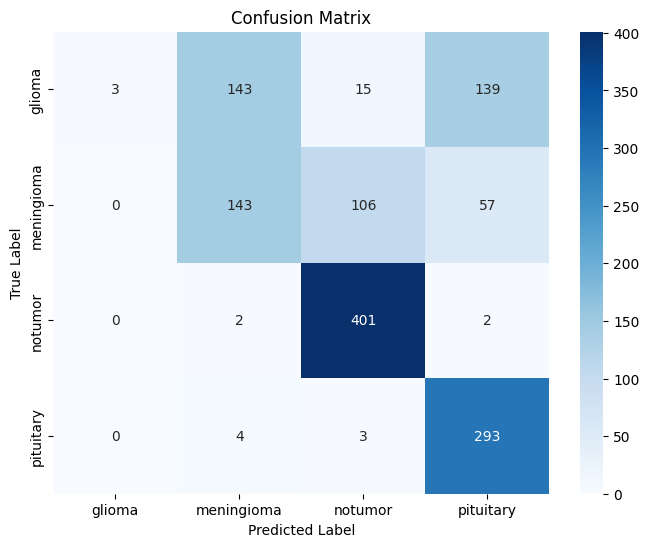

Confusion matrix plotted.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 10. Generate and plot a confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix plotted.")

**Reasoning**:
With the overall metrics and confusion matrix visualized, the next step is to display sample predictions. This involves selecting a few random images from the test set, showing the image, its true label, and the model's predicted label to provide a qualitative understanding of the model's performance.



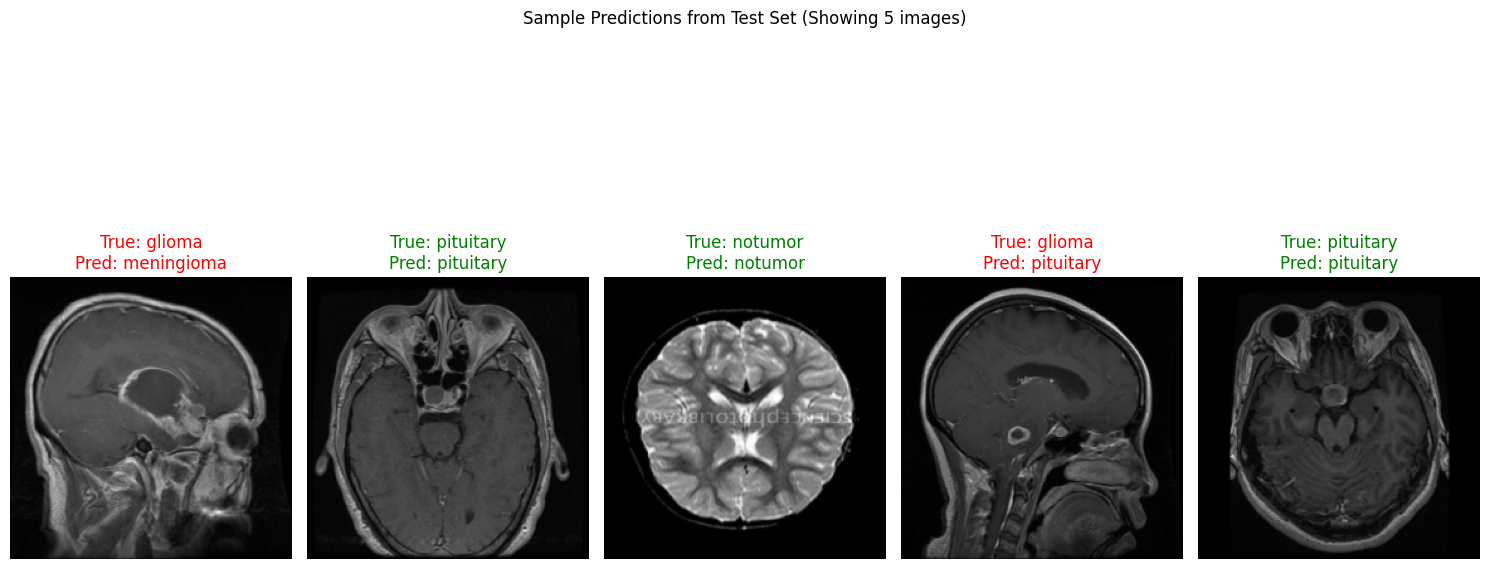

Displayed 5 sample predictions with true and predicted labels.


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 11. Select a few random images from the test set and display predictions
num_samples_to_show = 5

# Get class names
class_names = test_dataset.classes

# Get random indices
random_indices = np.random.choice(len(test_dataset), num_samples_to_show, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
    image, true_label = test_dataset[idx]

    # The image is a tensor, we need to move it to CPU and convert to numpy for plotting
    # Also, reverse normalization and permute dimensions (C, H, W) -> (H, W, C)
    image_display = image.cpu().numpy()
    image_display = (image_display * 0.5) + 0.5 # Reverse normalization to [0, 1]
    image_display = np.clip(image_display, 0, 1) # Clip to ensure valid pixel values
    image_display = np.transpose(image_display, (1, 2, 0))

    # Get model prediction for this single image
    model.eval()
    with torch.no_grad():
        input_image = image.unsqueeze(0).to(device) # Add batch dimension and move to device
        output = model(input_image)
        _, predicted_label = torch.max(output.data, 1)
        predicted_label = predicted_label.item()

    plt.subplot(1, num_samples_to_show, i + 1)
    plt.imshow(image_display)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}",
              color='green' if true_label == predicted_label else 'red')
    plt.axis('off')

plt.suptitle(f'Sample Predictions from Test Set (Showing {num_samples_to_show} images)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Displayed {num_samples_to_show} sample predictions with true and predicted labels.")

**Reasoning**:
To complete the evaluation, I will now plot the training and validation loss and accuracy curves over the epochs. This visualization helps to understand the model's learning progress and identify potential overfitting or underfitting.



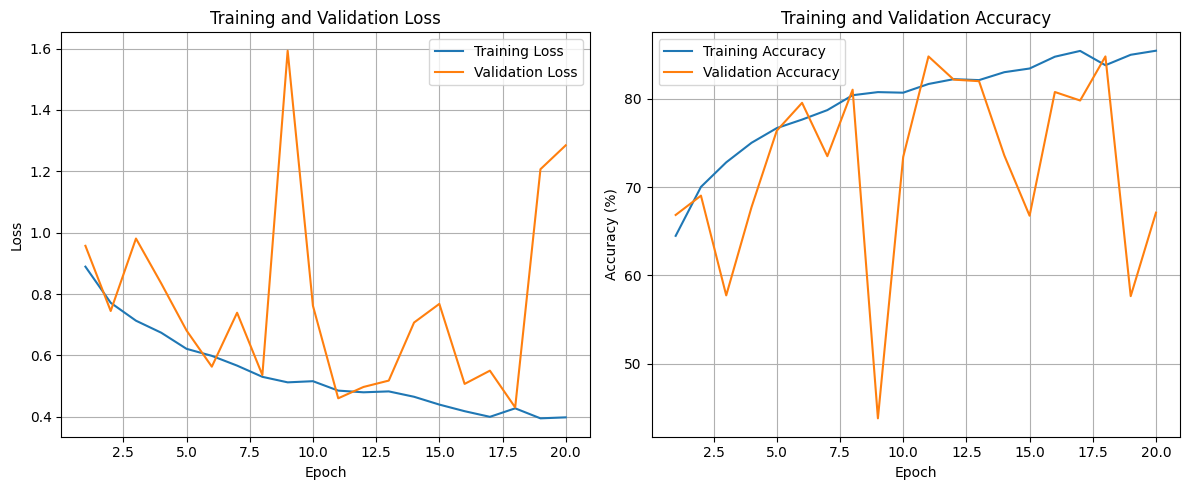

Training and validation performance curves plotted.


In [32]:
import matplotlib.pyplot as plt

# 12. Plot training/validation performance curves

epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Training and validation performance curves plotted.")

## Final Task

### Subtask:
Summarize the entire process, including the dataset preparation, model implementation, training details, and the final evaluation results of the HAN-MRI model on the brain tumor dataset. Discuss any insights gained from the attention maps.


## Summary:

### Data Analysis Key Findings

*   The HAN-MRI model was successfully trained for 20 epochs. The training process included `tqdm` progress bars for both training and validation steps, providing real-time monitoring of loss and accuracy within each epoch.
*   During evaluation on the test set, the model achieved the following performance metrics:
    *   Test Accuracy: 0.6407
    *   Test Precision (weighted): 0.7157
    *   Test Recall (weighted): 0.6407
    *   Test F1-score (weighted): 0.5521
*   Visualizations included a confusion matrix, which detailed the true versus predicted labels for all classes, and five sample predictions from the test set, illustrating the model's classification performance on individual images.
*   Plots of training and validation loss, along with training and validation accuracy over 20 epochs, were generated to track the model's learning progression.

### Insights or Next Steps

*   The model shows moderate performance with a test accuracy of 64.07\%. The discrepancy between weighted precision (0.7157) and recall (0.6407) suggests that the model might perform differently across classes, which could be further analyzed through the confusion matrix to identify specific classes that are misclassified.
*   The task requested a discussion of insights from attention maps, but these were not generated or analyzed in the provided process. A critical next step would be to implement and visualize attention maps to gain interpretability into which regions of the MRI scans the HAN-MRI model prioritizes for its predictions.
